In [4]:
import pandas as pd

# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

# 查看前五行
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
# 导入常用库
import pandas as pd
import numpy as np
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")
# 查看列名、数据类型、缺失值情况
print(df.info()) 
# 删除重复值
df.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [13]:
# 导入常用库
import pandas as pd
import numpy as np
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")
# 格式统一
df['gender'] = df['gender'].str.lower().str.strip()
df['lunch'] = df['lunch'].str.lower().str.strip()
df['test preparation course'] = df['test preparation course'].str.lower().str.strip()
df['parental level of education'] = df['parental level of education'].str.lower().str.strip()

In [ ]:
# 导入常用库
import pandas as pd
import numpy as np
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")
# 检查数值范围异常，例如成绩不应超过100或小于0
for col in ['math score', 'reading score', 'writing score']:
    outliers = df[(df[col] < 0) | (df[col] > 100)]
    if not outliers.empty:
        print(f"{col} 存在异常值：")
        print(outliers)

        gender race/ethnicity parental level of education     lunch  \
count     1000           1000                        1000      1000   
unique       2              5                           6         2   
top     female        group C                some college  standard   
freq       518            319                         226       645   
mean       NaN            NaN                         NaN       NaN   
std        NaN            NaN                         NaN       NaN   
min        NaN            NaN                         NaN       NaN   
25%        NaN            NaN                         NaN       NaN   
50%        NaN            NaN                         NaN       NaN   
75%        NaN            NaN                         NaN       NaN   
max        NaN            NaN                         NaN       NaN   

       test preparation course  math score  reading score  writing score  
count                     1000  1000.00000    1000.000000    1000.000000

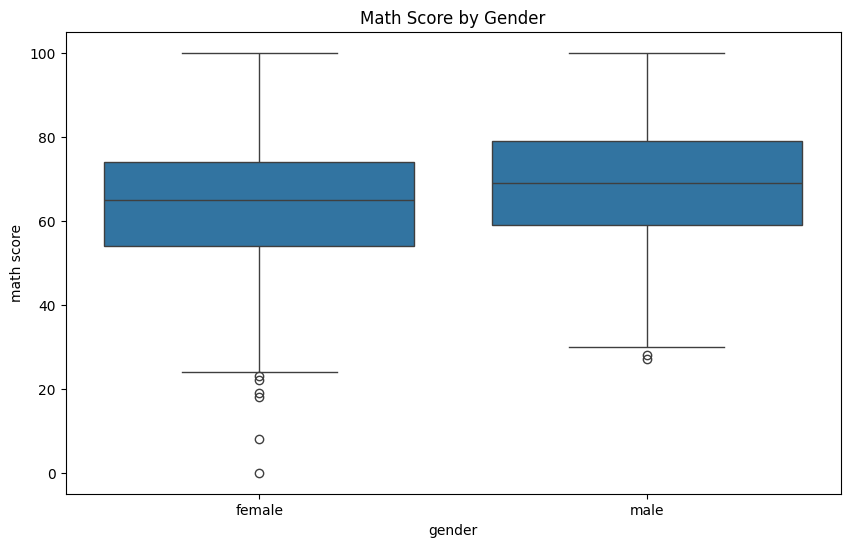

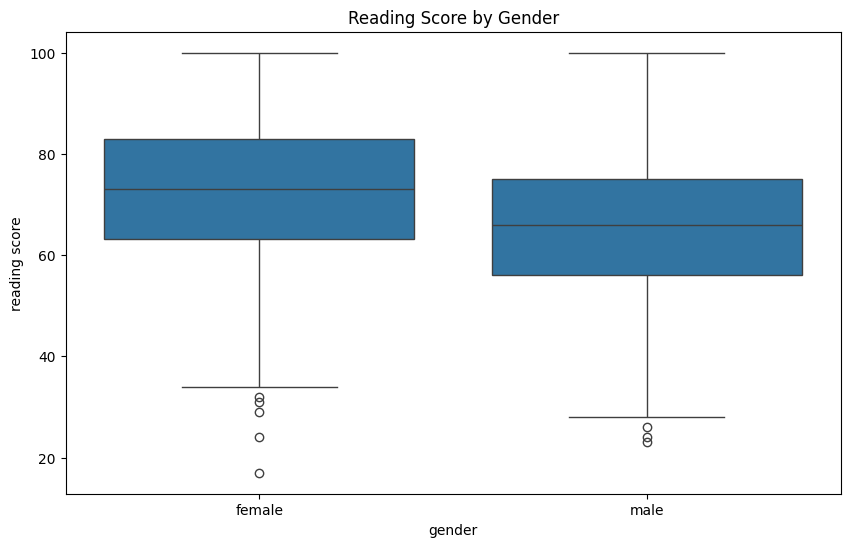

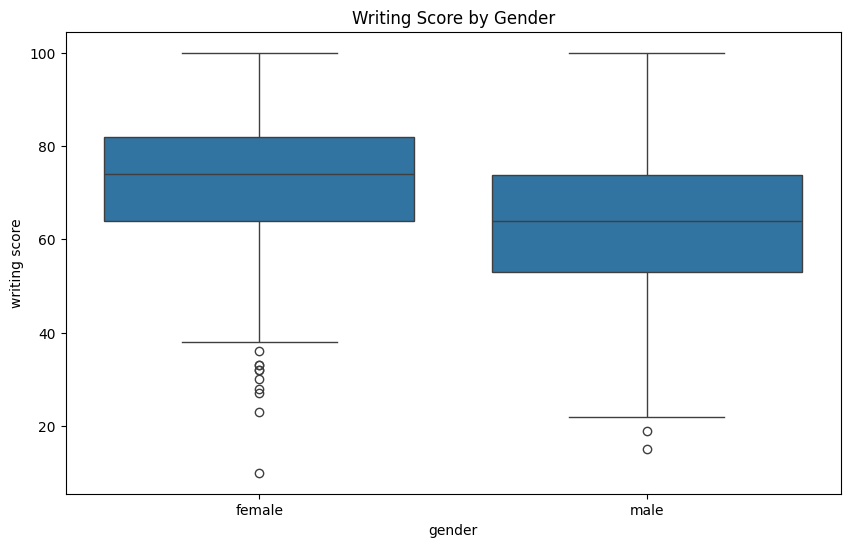

In [ ]:
#2.2.1 性别与成绩对比 — 箱线图（Boxplot）目的：分析不同性别在三科成绩上的差异。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='math score', data=df)
plt.title('Math Score by Gender')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='reading score', data=df)
plt.title('Reading Score by Gender')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='writing score', data=df)
plt.title('Writing Score by Gender')
plt.show()

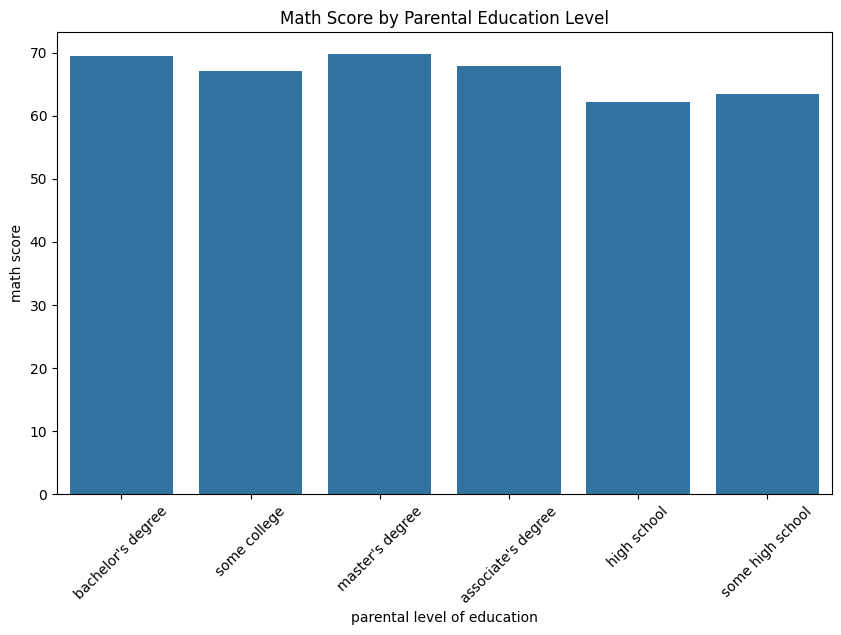

In [ ]:
#2.2.2 父母教育水平与学生成绩 — 条形图（Barplot）目的：探究家庭教育背景对学生成绩的影响。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(10, 6))
sns.barplot(x='parental level of education', y='math score', data=df, errorbar=None)
plt.xticks(rotation=45)
plt.title('Math Score by Parental Education Level')
plt.show()

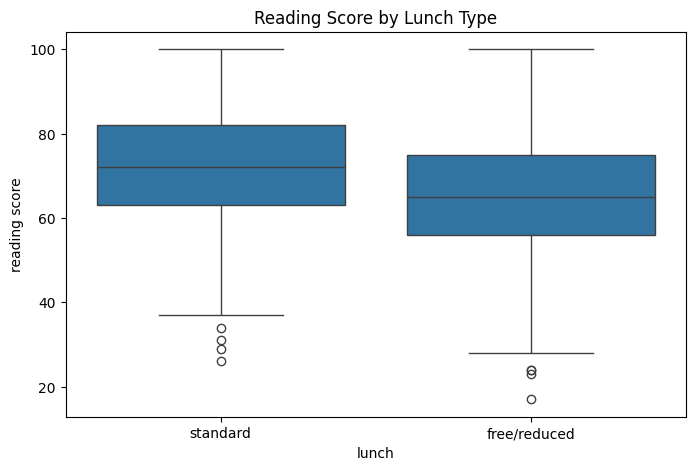

In [10]:
#2.2.3 午餐类型与成绩 — 箱线图 目的：探索学生经济背景与学习表现的关系。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(8, 5))
sns.boxplot(x='lunch', y='reading score', data=df)
plt.title('Reading Score by Lunch Type')
plt.show()

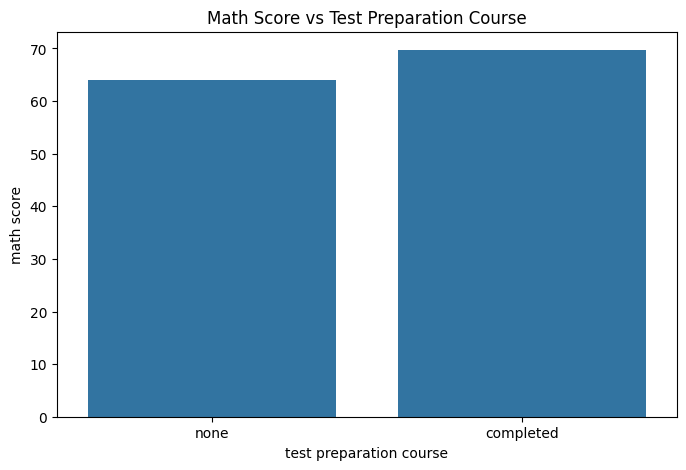

In [ ]:
#2.2.4 考试预备课程与成绩 — 条形图 目的：验证考试预备课程是否有效。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(8, 5))
sns.barplot(x='test preparation course', y='math score', data=df, errorbar=None)
plt.title('Math Score vs Test Preparation Course')
plt.show()

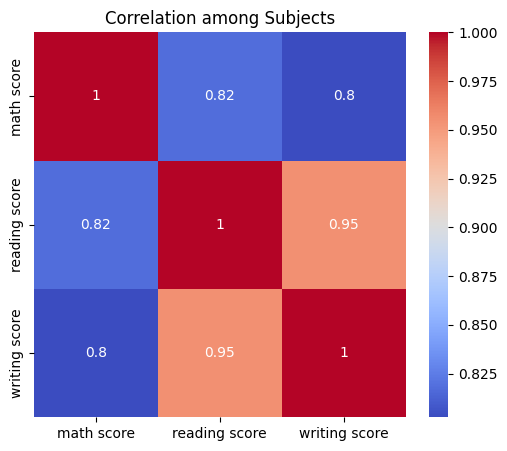

In [ ]:
#2.2.5 三科成绩相关性 — 热力图（Heatmap） 目的：分析科目之间的相关程度。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation among Subjects')
plt.show()

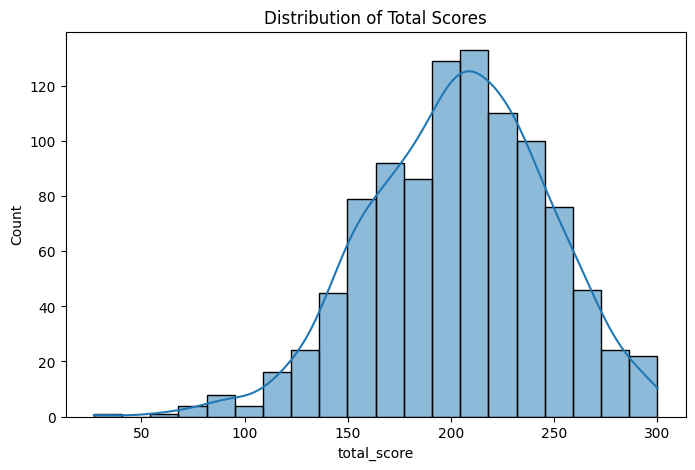

In [ ]:
#2.2.6 总成绩分布 — 直方图（Histogram） 目的：了解总体成绩分布，判断教学效果层次。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

df['total_score'] = df[['math score','reading score','writing score']].sum(axis=1)
plt.figure(figsize=(8, 5))
sns.histplot(df['total_score'], bins=20, kde=True)
plt.title('Distribution of Total Scores')
plt.show()

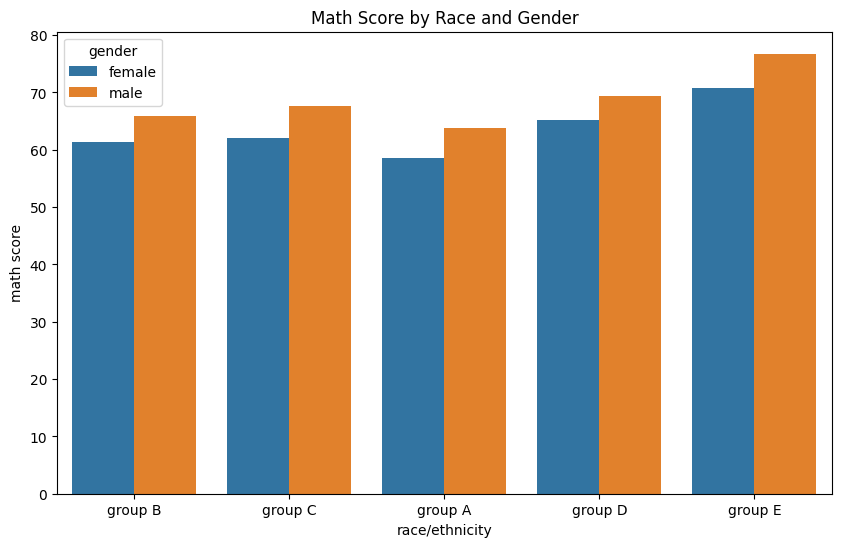

In [8]:
#2.2.7 不同族群平均成绩对比 — 分组柱状图 目的：了解不同群体的教育公平性。
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 读取数据
df = pd.read_csv(r"D:\NAU\8.进阶课CIT643\1\StudentsPerformance.csv")

plt.figure(figsize=(10, 6))
sns.barplot(x='race/ethnicity', y='math score', hue='gender', data=df, errorbar=None)
plt.title('Math Score by Race and Gender')
plt.show()